<a href="https://colab.research.google.com/github/carn51/Assignment-1/blob/main/9_50_11_4_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5PAM2034-0105-2025 - Assignment 3 - Data Analysis and Exploration

NAME:
STUDENT ID:

In this assignment, you are tasked with exploring a dataset using machine learning algorithms. You will train and evaluate a Random Forest Regressor to predict prices of regional flights in India.

You will need to write a short (1-2 page) report to accompany your code, explaining your results and analysis of the dataset.

In [1]:
#Module Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import ensemble

#Add any additional imports here


# Data Processing

The dataset used in this assignment can be found on [Kaggle](https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction). You will be using the data for the Economy class flights only, and will need to clean up the dataset.

Begin by loading in the economy.csv file, which is linked in the Canvas assignment, using pandas. You will need to derive new features from the data to create something you can train models with. The features in your training dataset should be:

FEATURES
1) Airline: The name of the airline company. Categorical.
2) Source City: City from which the flight takes off. Categorical.
3) Departure Time: Split the departure times into 3 categories based on the time, [Morning, Daytime, Night]. Categorical.
4) Stops: The number of stops on the flight path. Categorical.
5) Arrival Time: Split the departure times into 3 categories based on the time, [Morning, Daytime, Night]. Categorical.
6) Destination City: City where the flight will land. Categorical.
7) Duration: The number of hours the flight takes as a continuous real number. Continuous.
8) Lead Time: The number of days between the flight date and the booking date. Discrete.
11) Price: The cost of the flight. Continuous.

Drop any unused features from the dataset, such as the flight code, separate out the target variable and split into a training and testing set.

In [11]:
data = pd.read_csv('/content/economy.csv')
df = pd.DataFrame(data)
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"


In [12]:
#initial info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        206774 non-null  object
 1   airline     206774 non-null  object
 2   ch_code     206774 non-null  object
 3   num_code    206774 non-null  int64 
 4   dep_time    206774 non-null  object
 5   from        206774 non-null  object
 6   time_taken  206774 non-null  object
 7   stop        206774 non-null  object
 8   arr_time    206774 non-null  object
 9   to          206774 non-null  object
 10  price       206774 non-null  object
dtypes: int64(1), object(10)
memory usage: 17.4+ MB


Feature engineering

In [13]:
df['airline'] = df['airline'].astype('category')    #feat1
df['Source_City'] = df['from'].astype('category')    #feat2

#cleaning the dep_time column
#convert to string to remove colon then  back to integer for bins
df['dep_time'] = df['dep_time'].str.replace(':', '').astype(int)
#pd.cut to make categorical according to time:
#morning midnight to noon, daytime noon to 8, night 8 to midnight
bins = [0000, 1200, 2000, 2359]
labels = ['Morning', 'Daytime', 'Night']
df['dep_time'] = pd.cut(df['dep_time'], bins = bins, labels = labels)    #feat3

#replace with 0  if non stop else 1
#CHECK
df['stop'] = np.where(df['stop'] == 'non-stop', 1, 0)

#convert to categorical
df['stop'] = df['stop'].astype('category')    #feat 4

#also requires conversion
df['arr_time'] = df['arr_time'].str.replace(':', '').astype(int)
df['arr_time'] = pd.cut(df['arr_time'], bins = bins, labels = labels)      #feat 5

df['Destination_City'] = df['to'].astype('category')     #feat 6

#duration from time taken (many conversions)
#formatting
replace_vec = [('h', ''), ('m', ''), (' ', '')]

for old_, new_ in replace_vec:
  df['time_taken'] = df['time_taken'].str.replace(old_, new_)

#split into hours and minutes
for vals in df['time_taken'][-2:].astype(float):
  df['ttp2'] = vals/ 60 * 100

df['hours'] = df['time_taken'].str[:2]
df['duration'] = (df['hours'] + df['ttp2'].astype('str'))
df['duration'] = df['duration'].str.replace('.', '')
df['duration'] = df['duration'].str[:4]
df['duration'] = df['duration'].astype(float) / 100    #feat 7

from datetime import datetime

dates_list = []
#current format in df as string
format = '%d-%m-%Y'

#turn format
for datestrings in df['date']:
  dates_list.append(datetime.strptime(datestrings, format))

#all flights booked on this day
date0 = datetime(2022, 2, 11,0, 0)

days_between = []

for dates in dates_list:
  days_between.append(np.abs(date0 - dates))

df['lead_time'] = pd.Series(days_between).astype(int)    #feat 8

#target variable
df['price'] = df['price'].str.replace(',', '').astype(float)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   date              206774 non-null  object  
 1   airline           206774 non-null  category
 2   ch_code           206774 non-null  object  
 3   num_code          206774 non-null  int64   
 4   dep_time          206774 non-null  category
 5   from              206774 non-null  object  
 6   time_taken        206774 non-null  object  
 7   stop              206774 non-null  category
 8   arr_time          206774 non-null  category
 9   to                206774 non-null  object  
 10  price             206774 non-null  float64 
 11  Source_City       206774 non-null  category
 12  Destination_City  206774 non-null  category
 13  ttp2              206774 non-null  float64 
 14  hours             206774 non-null  object  
 15  duration          206774 non-null  float64 
 16  le

Preprocessing

In [15]:
catcols = df.select_dtypes(include = ['category']).columns.tolist()
print(catcols)

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
onehot_done = encoder.fit_transform(df[catcols]).toarray()
cols = encoder.get_feature_names_out(catcols)

onehot_df = pd.DataFrame(onehot_done, columns = cols)
df = pd.concat([df, onehot_df], axis = 1)
df.info()

['airline', 'dep_time', 'stop', 'arr_time', 'Source_City', 'Destination_City']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 44 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   date                        206774 non-null  object  
 1   airline                     206774 non-null  category
 2   ch_code                     206774 non-null  object  
 3   num_code                    206774 non-null  int64   
 4   dep_time                    206774 non-null  category
 5   from                        206774 non-null  object  
 6   time_taken                  206774 non-null  object  
 7   stop                        206774 non-null  category
 8   arr_time                    206774 non-null  category
 9   to                          206774 non-null  object  
 10  price                       206774 non-null  float64 
 11  Source_City                 206774 non

Dropping Unnecessary Columns

In [16]:
df = df.drop(columns = [
                       'airline',
                       'date', 'ch_code', 'num_code',
                       'time_taken',
                       'arr_time', 'dep_time',
                       'to', 'from',
                       'Source_City', 'Destination_City',
                       'ttp2', 'hours'])
df.head()


,stop,price,duration,lead_time,airline_Air India,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,airline_StarAir,...,Source_City_Delhi,Source_City_Hyderabad,Source_City_Kolkata,Source_City_Mumbai,Destination_City_Bangalore,Destination_City_Chennai,Destination_City_Delhi,Destination_City_Hyderabad,Destination_City_Kolkata,Destination_City_Mumbai
0,0,5953.0,2.4,0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,5953.0,2.4,0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,5956.0,2.4,0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,5955.0,2.4,0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,5955.0,2.4,0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Split

In [21]:
#define features
X=  df.drop(columns = ['price'])
y = df['price']
#y = np.sqrt(df['price'])
from sklearn.model_selection import train_test_split

#first, try with validaton data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=23)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=23)

# Model Training

Implement and train a random forest regressor, using sklearn. Explore a range of hyperparamter settings for the model to find the best fitting result.

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(bootstrap=True,
                               oob_score = True,
                               max_depth = 25,
                               max_features = 8,
                               min_samples_split = 6,
                               n_estimators = 500,
                               min_impurity_decrease=0.01,
                               )
rf_reg.fit(X_train, y_train)
y_preds = rf_reg.predict(X_test)

print(y_preds)

[2364.59303888 4527.04553264 4175.298384   ... 5279.2806967  4973.22017723
 6987.28410972]


# Analysis

Evaluate the results of your model, consider how the pricing of flights relates to other features in the dataset, such as the carrier or departure time, and use your trained model to support any conclusions. Create any relevant plots to include in your report.

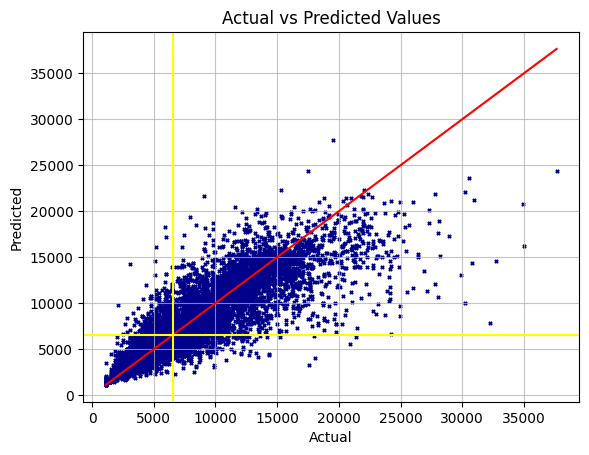

In [23]:

plt.scatter(y_test, y_preds, s=5, marker ='x', color='darkblue')    #INITIAL
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.axhline((df['price'].mean()), color='yellow')
plt.axvline((df['price'].mean()), color='yellow')
plt.title("Actual vs Predicted Values")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(alpha=0.75)
plt.show()

Scores

In [24]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_preds)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_preds)
print("R-squared:", r2)

print("Out-of-Bag Score:", rf_reg.oob_score_)

Mean Squared Error: 2770078.130432258
R-squared: 0.803753744440661
Out-of-Bag Score: 0.8082044211342778


Boxplot

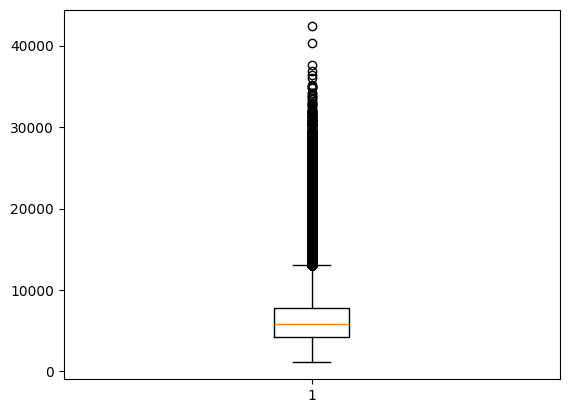

In [174]:
plt.boxplot(df['price'])
plt.show()

Repeat Analysis with less outliers

In [83]:
#overestimating
no_outliers = df[df['price'] < (df['price'].mean() + (df['price'].std()*2))]    #0.83 for 3 sd
no_outliers.head()


,stop,price,duration,lead_time,airline_Air India,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,airline_StarAir,...,Source_City_Delhi,Source_City_Hyderabad,Source_City_Kolkata,Source_City_Mumbai,Destination_City_Bangalore,Destination_City_Chennai,Destination_City_Delhi,Destination_City_Hyderabad,Destination_City_Kolkata,Destination_City_Mumbai
0,0,5953.0,2.4,0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,5953.0,2.4,0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,5956.0,2.4,0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,5955.0,2.4,0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,5955.0,2.4,0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Split

In [84]:
#define features
X=  no_outliers.drop(columns = ['price', 'stop', 'stop_0'])    #no difference without stops
y = no_outliers['price']
#y = np.sqrt(df['price'])
from sklearn.model_selection import train_test_split

#first, try with validaton data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=23)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=23)

Model

In [85]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(bootstrap=True,
                               oob_score = True,
                               max_depth = 25,
                               max_features = 8,
                               min_samples_split = 6,
                               n_estimators = 500,
                               min_impurity_decrease=0.01,
                               )
rf_reg.fit(X_train, y_train)
y_preds = rf_reg.predict(X_test)

print(len(y_preds))

19656


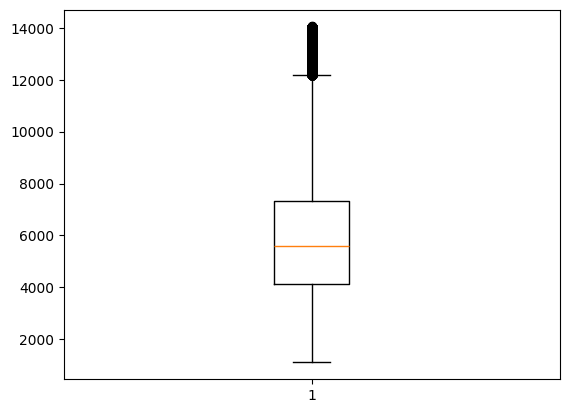

In [86]:
plt.boxplot(no_outliers['price'])
plt.show()

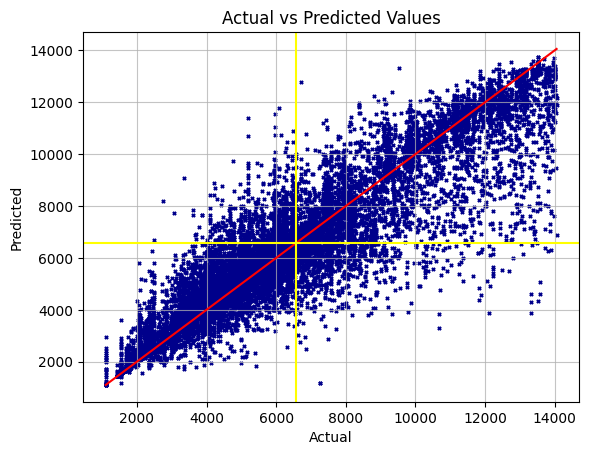

In [87]:

plt.scatter(y_test, y_preds, s=5, marker ='x', color='darkblue')    #INITIAL
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.axhline((df['price'].mean()), color='yellow')
plt.axvline((df['price'].mean()), color='yellow')
plt.title("Actual vs Predicted Values")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(alpha=0.75)
plt.show()

In [88]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_preds)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_preds)
print("R-squared:", r2)

print("Out-of-Bag Score:", rf_reg.oob_score_)

Mean Squared Error: 1216522.847236015
R-squared: 0.8445261877154305
Out-of-Bag Score: 0.8445149335055052
